In [1]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [3]:
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [25]:
def train_with_scheduler(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler, 
	scheduler, 
	clip_grad=False
	):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		warmup_scheduler.step()

		# Training 
		losses = []
		metric.reset()

		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			losses.append(loss.item())
			loss.backward()
			if clip_grad:
				nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
			optimizer.step()
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = np.mean(losses)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		lr = optimizer.param_groups[0]['lr']

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}, '
			+f'LR: {lr}'
		)

		if epoch >= 5:
			scheduler.step()
			print(f"learning rate: {scheduler.get_last_lr()[0]}")
		
		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

In [24]:
0.1*0.9*0.9

0.08100000000000002

C:\Users\user\AppData\Local\Temp\ipykernel_14116\4124022275.py:19: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warmup_scheduler.step()


Epoch: 1/30, Loss: 0.926, Train Metric: 0.653, Valid Metric: 0.49, LR: 0.028000000000000004
Epoch: 2/30, Loss: 0.446, Train Metric: 0.47, Valid Metric: 0.457, LR: 0.046000000000000006
Epoch: 3/30, Loss: 0.398, Train Metric: 0.45, Valid Metric: 0.427, LR: 0.064
Epoch: 4/30, Loss: 0.391, Train Metric: 0.441, Valid Metric: 0.454, LR: 0.082
Epoch: 5/30, Loss: 0.418, Train Metric: 0.44, Valid Metric: 0.422, LR: 0.1
Epoch: 6/30, Loss: 0.392, Train Metric: 0.427, Valid Metric: 0.43, LR: 0.1
learning rate: 0.09000000000000001
Epoch: 7/30, Loss: 0.348, Train Metric: 0.414, Valid Metric: 0.416, LR: 0.09000000000000001
learning rate: 0.08100000000000002
Epoch: 8/30, Loss: 0.368, Train Metric: 0.406, Valid Metric: 0.421, LR: 0.08100000000000002
learning rate: 0.07290000000000002
Epoch: 9/30, Loss: 0.332, Train Metric: 0.399, Valid Metric: 0.4, LR: 0.07290000000000002
learning rate: 0.06561000000000002
Epoch: 10/30, Loss: 0.343, Train Metric: 0.391, Valid Metric: 0.388, LR: 0.06561000000000002
lear

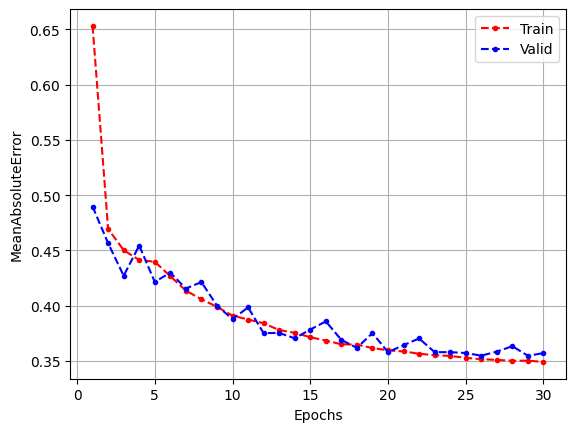

In [26]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.MeanAbsoluteError().to(device)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history = train_with_scheduler(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	warmup_scheduler, 
	scheduler,
	clip_grad=True,
	)
plot_history(history, n_epochs, metric)


In [27]:
from custom_utils import train, plot_history

In [ ]:
from torch.up

In [ ]:
learning_rate = 0.1
n_epochs=30

model = nn.Sequential(
	nn.Linear(in_features=8, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=1),
).to(device)

criterion = nn.MSELoss()
# optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
optimizer = torch.optim.Adam(params=model.parameters())
metric = torchmetrics.MeanAbsoluteError().to(device)
# warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR (optimizer, T_max=5, eta_min=1e-6)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs, 
	# warmup_scheduler=warmup_scheduler, 
	# scheduler=scheduler, 
	patience=None,
	checkpoint_path='best_model.pt',
	restore_best_model=True,
	clip_grad_norm=True
)

Epoch: 1/30, Train Loss: 0.859, Train Metric: 0.638, Valid Metric: 0.501, Learning Rate: 0.028, Time: 0.84s
	Checkpoint, valid metric: 0.501
Epoch: 2/30, Train Loss: 0.438, Train Metric: 0.465, Valid Metric: 0.464, Learning Rate: 0.046, Time: 0.71s
	Checkpoint, valid metric: 0.464
Epoch: 3/30, Train Loss: 0.405, Train Metric: 0.446, Valid Metric: 0.464, Learning Rate: 0.064, Time: 0.74s
	Checkpoint, valid metric: 0.464
Epoch: 4/30, Train Loss: 0.391, Train Metric: 0.436, Valid Metric: 0.432, Learning Rate: 0.082, Time: 0.71s
	Checkpoint, valid metric: 0.432
Epoch: 5/30, Train Loss: 0.383, Train Metric: 0.435, Valid Metric: 0.416, Learning Rate: 0.100, Time: 0.67s
	Checkpoint, valid metric: 0.416
Epoch: 6/30, Train Loss: 0.368, Train Metric: 0.426, Valid Metric: 0.425, Learning Rate: 0.100, Time: 0.68s
Epoch: 7/30, Train Loss: 0.355, Train Metric: 0.415, Valid Metric: 0.394, Learning Rate: 0.100, Time: 0.8s
	Checkpoint, valid metric: 0.394
Epoch: 8/30, Train Loss: 0.347, Train Metric: 0

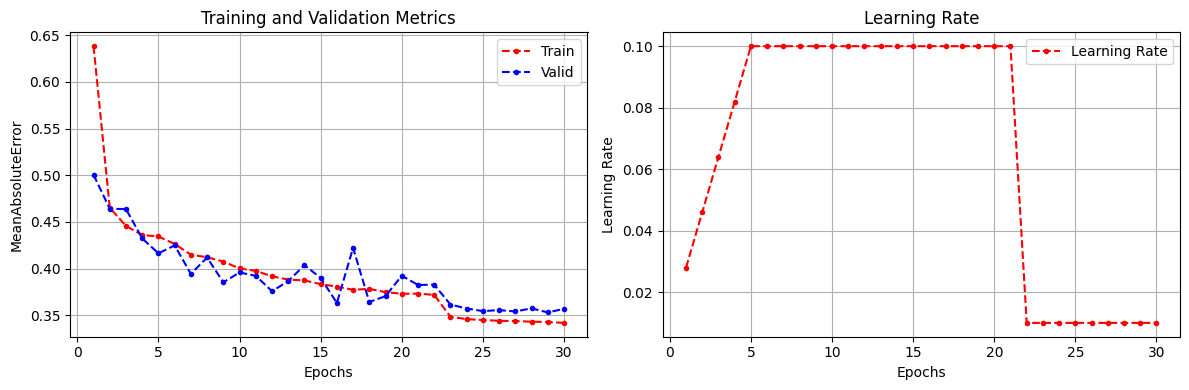

In [37]:
plot_history(history, metric)